In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/makeup_sales_dataset_2025.csv")
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


In [6]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD
count,500.000000,500.000000,500.000000,500.00000
mean,250.500000,62.857760,25.416000,1586.37700
std,144.481833,32.609632,14.217426,1284.13365
min,1.000000,5.250000,1.000000,25.64000
25%,125.750000,35.512500,13.000000,536.67250
50%,250.500000,61.225000,26.000000,1241.12500
75%,375.250000,90.775000,37.000000,2345.87750
max,500.000000,119.930000,50.000000,5987.50000


In [7]:
df.isnull().sum()

,0
Sale_ID,0
Date,0
Brand,0
Product_Type,0
Country,0
Sales_Channel,0
Payment_Method,0
Price_USD,0
Units_Sold,0
Revenue_USD,0


In [8]:
print("Initial DataFrame shape:", df.shape)

# 1. Remove null values (already checked, no nulls found)
print("Null values before cleaning:\n", df.isnull().sum())

# 2. Fix data types
df['Date'] = pd.to_datetime(df['Date'])

# 3. Remove duplicates
df.drop_duplicates(inplace=True)
print("DataFrame shape after removing duplicates:", df.shape)

# 4. Handle outliers (skipped for now as per general request, often requires more specific instructions)

# 5. Standardize categories (convert string columns to consistent case)
for col in ['Brand', 'Product_Type', 'Country', 'Sales_Channel', 'Payment_Method']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.title()

print("\nData types after fixing 'Date' column:")
df.info()

# Create a clean dataset
df.to_csv('clean_makeup_sales.csv', index=False)
print("\nCleaned data saved to 'clean_makeup_sales.csv'")
print("First 5 rows of cleaned data:")
print(df.head())

Initial DataFrame shape: (500, 10)
Null values before cleaning:
 Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64
DataFrame shape after removing duplicates: (500, 10)

Data types after fixing 'Date' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Sale_ID         500 non-null    int64         
 1   Date            500 non-null    datetime64[ns]
 2   Brand           500 non-null    object        
 3   Product_Type    500 non-null    object        
 4   Country         500 non-null    object        
 5   Sales_Channel   500 non-null    object        
 6   Payment_Method  500 non-null    object        
 7   Price_USD       500 non-null    float64       
 8  

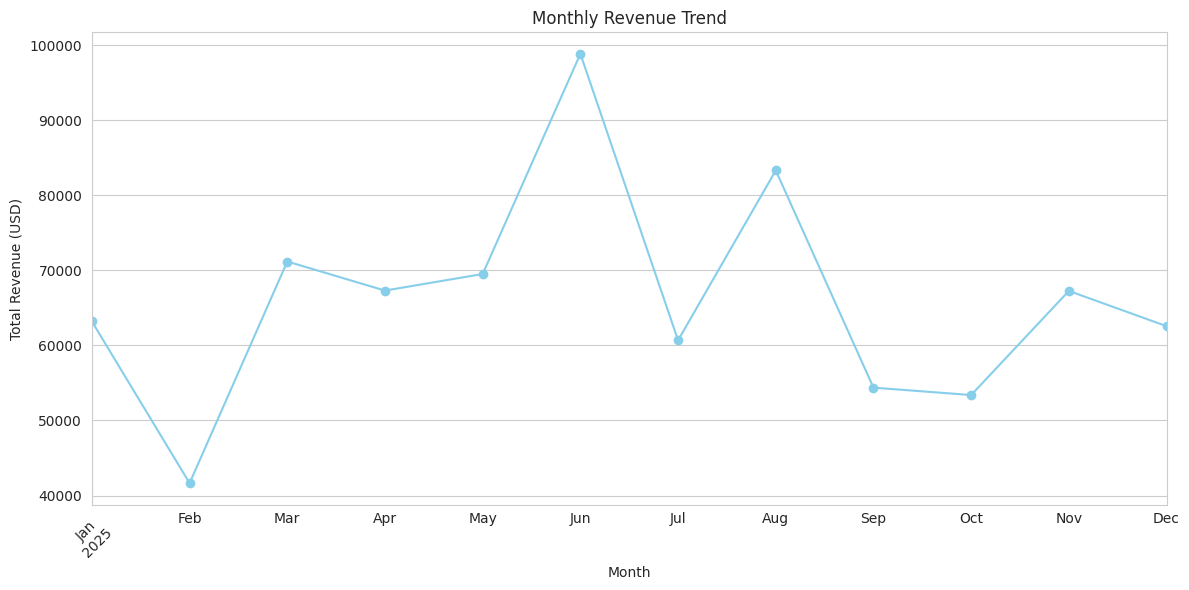

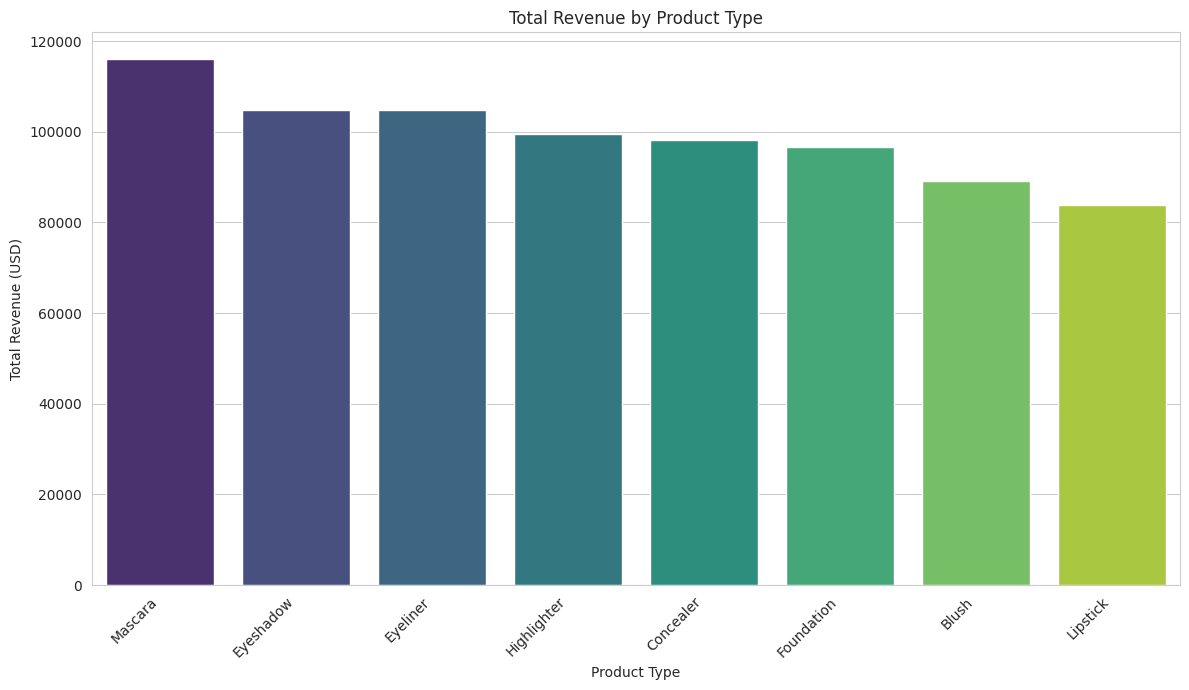

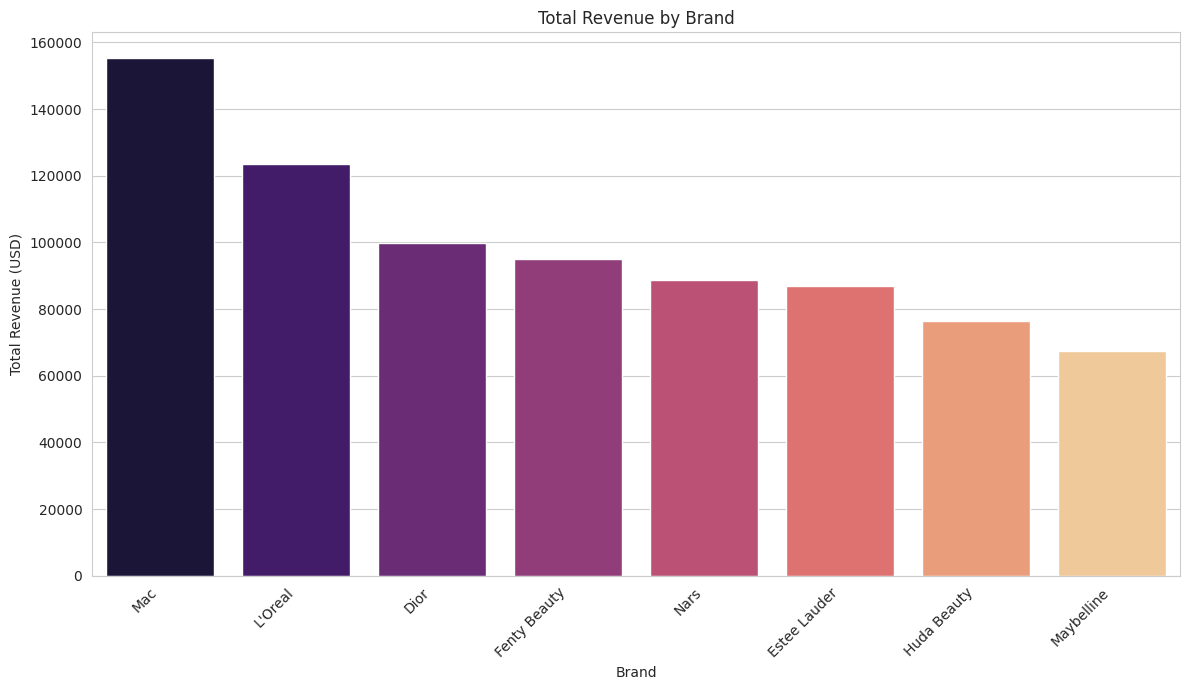

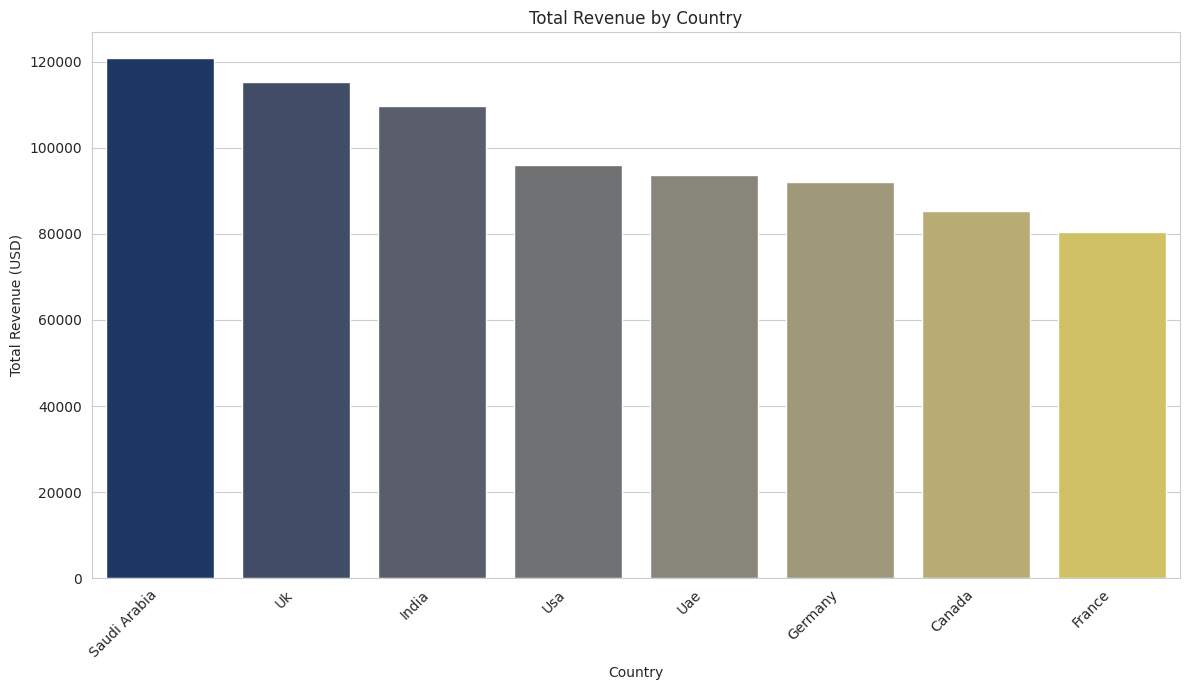

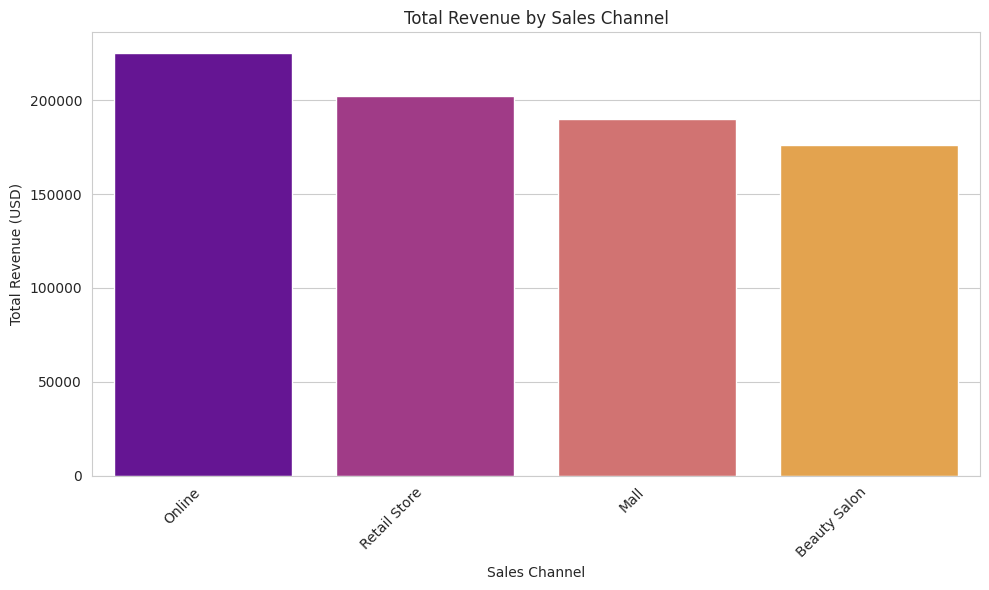

In [9]:
# Set plot style
sns.set_style("whitegrid")

# 1. Revenue Trends Over Time (Monthly)
# Ensure 'Date' is datetime and 'Month' is created if not already present
if 'Date' not in df.columns or df['Date'].dtype != '<M8[ns]':
    df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue_USD'].sum().sort_index()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='skyblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Sales by Product Type
revenue_by_product_type = df.groupby('Product_Type')['Revenue_USD'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=revenue_by_product_type.index, y=revenue_by_product_type.values, palette='viridis', hue=revenue_by_product_type.index, legend=False)
plt.title('Total Revenue by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 3. Top Brands by Revenue
revenue_by_brand = df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=revenue_by_brand.index, y=revenue_by_brand.values, palette='magma', hue=revenue_by_brand.index, legend=False)
plt.title('Total Revenue by Brand')
plt.xlabel('Brand')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 4. Customer Segmentation by Country (or geographical segmentation)
revenue_by_country = df.groupby('Country')['Revenue_USD'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=revenue_by_country.index, y=revenue_by_country.values, palette='cividis', hue=revenue_by_country.index, legend=False)
plt.title('Total Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 5. Customer Segmentation by Sales Channel
revenue_by_sales_channel = df.groupby('Sales_Channel')['Revenue_USD'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_sales_channel.index, y=revenue_by_sales_channel.values, palette='plasma', hue=revenue_by_sales_channel.index, legend=False)
plt.title('Total Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# 1. Verify/Recalculate Revenue (Price * Quantity)
# Check if Revenue_USD is consistent with Price_USD * Units_Sold
# df['Revenue_USD'] already exists, let's verify its correctness
df['Calculated_Revenue'] = df['Price_USD'] * df['Units_Sold']

# Compare existing Revenue_USD with the calculated one
# Using .round() to handle potential floating point inaccuracies
if not (df['Revenue_USD'].round(2) == df['Calculated_Revenue'].round(2)).all():
    print("Warning: Existing 'Revenue_USD' does not perfectly match 'Price_USD * Units_Sold'. Recalculating.")
    df['Revenue_USD'] = df['Calculated_Revenue']
else:
    print("Existing 'Revenue_USD' is consistent with 'Price_USD * Units_Sold'. No recalculation needed.")

df.drop(columns=['Calculated_Revenue'], inplace=True, errors='ignore')

print("\nUpdated DataFrame head after revenue check:")
print(df.head())

# 2. Month / Year / Day of Week extraction
# 'Date' column is already datetime type, and 'Month' (period[M]) was created for EDA
# Extract year and a numerical month if not already present

if 'Year' not in df.columns:
    df['Year'] = df['Date'].dt.year
    print("Created 'Year' column.")

if 'Month_Name' not in df.columns:
    df['Month_Name'] = df['Date'].dt.month_name()
    print("Created 'Month_Name' column.")

if 'Day_of_Week' not in df.columns:
    df['Day_of_Week'] = df['Date'].dt.day_name()
    print("Created 'Day_of_Week' column.")

print("\nData types after adding new date features:")
df.info()
print("\nFirst 5 rows with new date features:")
print(df[['Date', 'Month', 'Year', 'Month_Name', 'Day_of_Week']].head())

# 3. Customer Lifetime Value (CLV)
# This dataset does not contain unique customer IDs, which are essential for calculating CLV per customer.
# CLV typically involves:
#    - Identifying individual customers
#    - Tracking their purchase frequency and value over time
#    - Using models (e.g., RFM, probabilistic models) to predict future value

# Since we lack a 'Customer_ID', direct CLV calculation is not possible with this dataset.
# If a 'Customer_ID' column were available, the steps would generally involve:
#  a. Grouping data by Customer_ID
#  b. Calculating metrics like frequency (number of purchases), recency (days since last purchase),
#     and monetary value (total spend) for each customer.
#  c. Applying a CLV model or heuristic based on these metrics.

print("\nNote on Customer Lifetime Value (CLV):")
print("This dataset lacks unique 'Customer_ID' to calculate Customer Lifetime Value (CLV) per customer.")
print("CLV requires tracking individual customer purchase behavior over time.")

Existing 'Revenue_USD' is consistent with 'Price_USD * Units_Sold'. No recalculation needed.

Updated DataFrame head after revenue check:
   Sale_ID       Date         Brand Product_Type  Country Sales_Channel  \
0        1 2025-11-24  Fenty Beauty     Eyeliner      Uae  Retail Store   
1        2 2025-02-22       L'Oreal  Highlighter      Usa        Online   
2        3 2025-04-22    Maybelline     Eyeliner  Germany  Retail Store   
3        4 2025-10-29           Mac  Highlighter   France          Mall   
4        5 2025-04-21       L'Oreal     Lipstick  Germany        Online   

   Payment_Method  Price_USD  Units_Sold  Revenue_USD    Month  
0  Digital Wallet      17.80          48       854.40  2025-11  
1            Cash      82.82          35      2898.70  2025-02  
2            Card      31.76          39      1238.64  2025-04  
3            Cash      36.99           1        36.99  2025-10  
4            Card     115.08          22      2531.76  2025-04  
Created 'Year' column